In [1]:
from pathlib import Path
import numpy as np

from vascx.faz.retina import FAZRetina
from vascx.utils.analysis import (
    extract_in_parallel,
)
from rtnls_enface.utils.data_loading import open_mask


In [2]:
ds_path = Path('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ')

In [3]:
images_paths = sorted(list(ds_path.glob('*_OCTA.png')))
masks_paths = sorted(list(ds_path.glob('*_AV_Map.png')))
faz_paths = sorted(list(ds_path.glob('*_FAZ.png')))

In [4]:
def av_loader(fpath, *args):
    im = open_mask(fpath)

    if len(im.shape) == 3:
        im = im[...,0]

    return {
        "arteries": (im == 127),
        "veins": (im==255),
    }

In [5]:
items = [{'id': im_path.stem, 'av_path': av_path, 'image_path': im_path, 'faz_path': faz_path, 'av_loader': av_loader} for im_path, av_path, faz_path, in zip(images_paths, masks_paths, faz_paths)]

In [6]:
avf = av_loader('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/1081_L_116151_0_AV_Map.png')

In [7]:
avfp = av_loader('/mnt/oogergo/eyened/sinergia/chuv_octa_samples/26_R_144357_0_AV_map.png')

In [8]:
items

[{'id': '1081_L_116151_0_OCTA',
  'av_path': PosixPath('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/1081_L_116151_0_AV_Map.png'),
  'image_path': PosixPath('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/1081_L_116151_0_OCTA.png'),
  'faz_path': PosixPath('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/1081_L_116151_0_FAZ.png'),
  'av_loader': <function __main__.av_loader(fpath, *args)>},
 {'id': '63_R_104686_0_OCTA',
  'av_path': PosixPath('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/63_R_104686_0_AV_Map.png'),
  'image_path': PosixPath('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/63_R_104686_0_OCTA.png'),
  'faz_path': PosixPath('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/63_R_104686_0_FAZ.png'),
  'av_loader': <function __main__.av_loader(fpath, *args)>},
 {'id': '663_L_101955_0_OCTA',
  'av_path': PosixPath('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/663_L_101955_0_AV_Map.png'),
  'image_path': PosixPath('/mnt/oogergo/eyened/sinergia/faz_samples/FAZ/663_L_101955_0_OCTA.png'),
  

In [9]:
ret = FAZRetina.from_file(**items[0])

<Axes: >

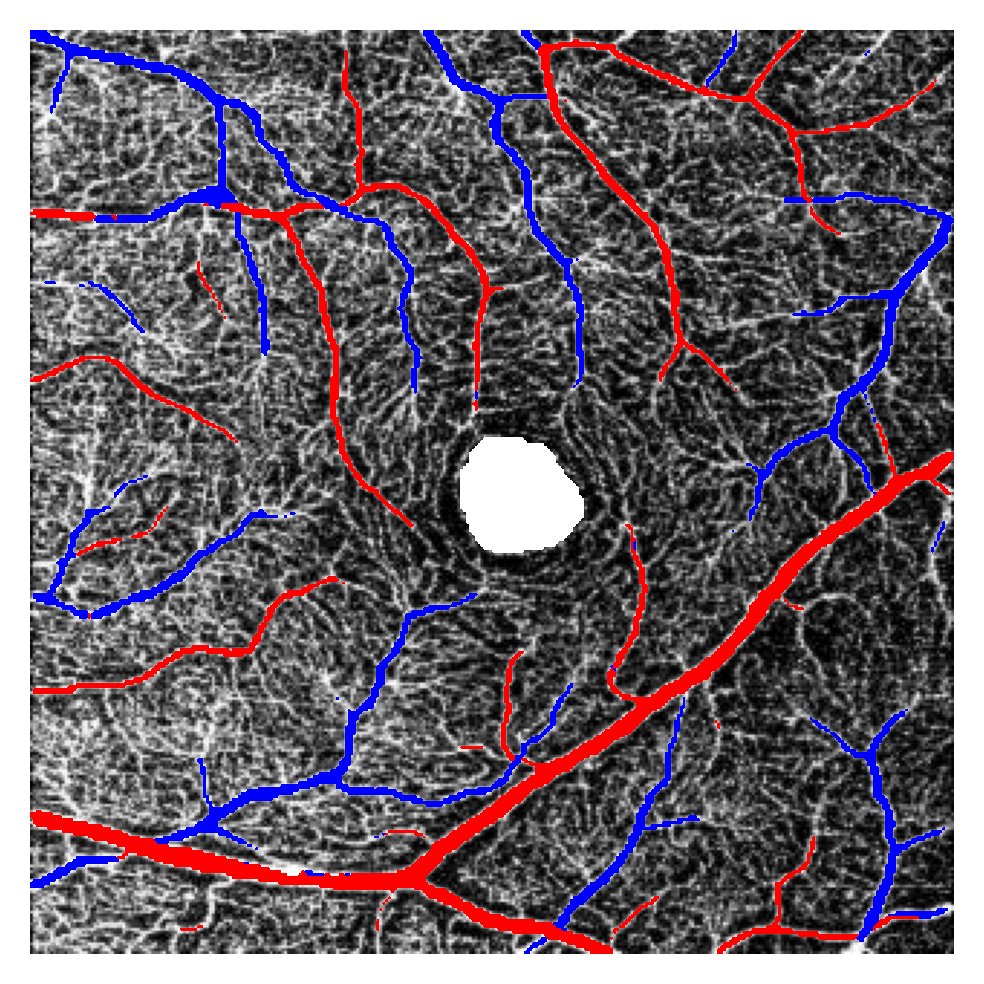

In [10]:
ret.plot()

In [12]:
df = extract_in_parallel(items, 'basic', retina_cls=FAZRetina)

100%|██████████| 7/7 [00:00<00:00, 9203.80it/s]
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.9s
[Parallel(n_jobs=8)]: Done   2 out of   7 | elapsed:    0.9s remaining:    2.3s
[Parallel(n_jobs=8)]: Done   3 out of   7 | elapsed:    1.0s remaining:    1.3s
[Parallel(n_jobs=8)]: Done   4 out of   7 | elapsed:    1.0s remaining:    0.7s
[Parallel(n_jobs=8)]: Done   5 out of   7 | elapsed:    1.0s remaining:    0.4s
[Parallel(n_jobs=8)]: Done   7 out of   7 | elapsed:    4.6s finished


In [13]:
df.columns

Index(['vd_arteries', 'vd_veins', 'vd_inner_arteries', 'vd_inner_veins',
       'vd_outer_arteries', 'vd_outer_veins', 'vd_superior_arteries',
       'vd_superior_veins', 'vd_inferior_arteries', 'vd_inferior_veins',
       'vd_left_arteries', 'vd_left_veins', 'vd_right_arteries',
       'vd_right_veins', 'faz_perimeter_arteries', 'faz_perimeter_veins',
       'faz_area_arteries', 'faz_area_veins', 'diam_arteries_median',
       'diam_arteries_std', 'diam_veins_median', 'diam_veins_std',
       'tort_arteries', 'tort_veins', 'bif_arteries', 'bif_veins'],
      dtype='object')

In [15]:
df[['faz_perimeter_veins']]

,faz_perimeter_veins
1081_L_116151_0_OCTA,136.225395
63_R_104686_0_OCTA,92.083260
663_L_101955_0_OCTA,186.752307
834_L_99642_0_OCTA,152.468036
834_R_99635_0_OCTA,137.154328
917_L_134651_0_OCTA,184.367530
917_R_134646_0_OCTA,174.024385
